# Import and setup

In [6]:
import os
if os.path.exists('digit_recognizer'):
    !rm -rf digit_recognizer
!git clone https://github.com/Sirius-Siru/digit_recognizer.git

import sys
if '/content/digit_recognizer' not in sys.path:
    sys.path.append('/content/digit_recognizer')

!pip install -q kaggle

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

if os.path.isdir('data') and os.path.exists('data/train.csv'):
    print("✨ Dữ liệu đã sẵn sàng, không cần tải lại.")
else:
    print("🚀 Đang tải dữ liệu...")
    !kaggle competitions download -c digit-recognizer
    !unzip -o digit-recognizer.zip -d data
    !rm -f digit-recognizer.zip

Cloning into 'digit_recognizer'...
remote: Enumerating objects: 42, done.
remote: Counting objects: 100% (42/42), done.
remote: Compressing objects: 100% (30/30), done.
remote: Total 42 (delta 16), reused 38 (delta 12), pack-reused 0 (from 0)
Receiving objects: 100% (42/42), 30.79 KiB | 15.40 MiB/s, done.
Resolving deltas: 100% (16/16), done.
✨ Dữ liệu đã sẵn sàng, không cần tải lại.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from src.clean_data import normalize
from src.extract_hog import extract_hog
import src.evaluate as eva

# Load data

In [9]:
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')

#Clean data
train, test = normalize(train, test)

# Preprocessing

In [18]:
# This cell use to unflatten image
X = train.drop('label', axis = 1)
y = train['label']
img = X.values.reshape(-1, 28, 28)


In [19]:
# This cell use to Histogram of Oriented Gradients (HOG)
X_hog = [extract_hog(image) for image in img]

In [20]:
X_combined = np.hstack((X, X_hog))

In [21]:
# This cell use to split train-test

X_train, X_test, y_train, y_test = train_test_split(X_combined, y, test_size = 0.2, random_state = 42)

# Model selection + Train model

In [23]:
model = RandomForestClassifier(n_estimators = 100, oob_score=True, random_state = 42)

model.fit(X_train, y_train)

RandomForestClassifier(oob_score=True, random_state=42)

# Evaluation

OOB Score: 0.9719642857142857
Accuracy = 97.58


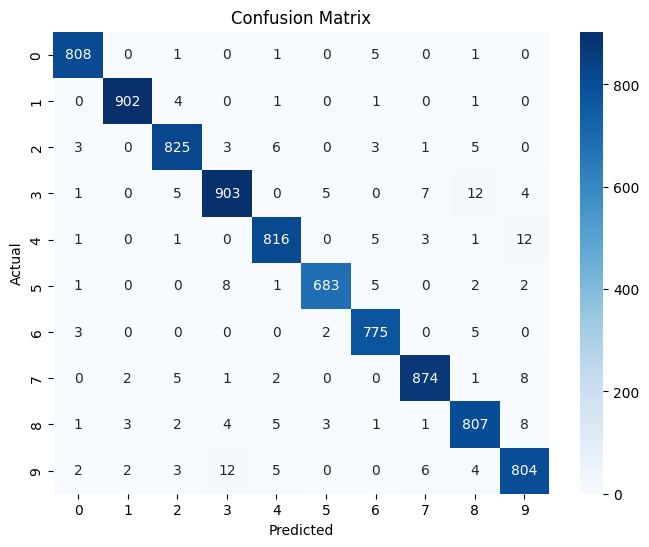

AttributeError: 'numpy.ndarray' object has no attribute 'iloc'

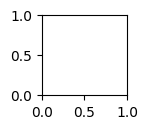

In [30]:
y_pred = model.predict(X_test)
print(f'OOB Score: {model.oob_score_}')
eva.evaluate(y_test, y_pred)
eva.showWrongCase(model, X_test, y_test) 

# Submission